# Prac W7 - Multilayer Perceptron Neural Networks

(**Q1**) The XOR dataset is a classic toy problem in the history of neural networks. Use the code 
provided to try and train a 2-2-1 MLP to learn XOR. Use the code to verify for yourself the 
following key ponts:

- The result of the training is sensitive to the initialisation of the weights
- The result of the training is sensitive to the learning rate
- The result of the training is sensitive to the number of epochs/weight updates
- The result of the training is sensitive to the scale of the data

In [4]:
import numpy as np
import pandas as pd

from numpy.typing import NDArray
from typing import List

In [5]:
rng = np.random.default_rng()

def get_misclassification_rate(y_pred: NDArray[np.int64], y_true: NDArray[np.int64]) -> float:
    return 1 - np.sum(y_pred == y_true) / y_pred.shape[0]

class MLP:
    # Data Members
    learning_rate: float
    epochs: int
    weights: List[NDArray[np.float64]]
    bias: List[NDArray[np.float64]]
    neuron_values: List[NDArray[np.float64]]
    layer_sizes: List[int] | NDArray[np.int64]

    # Private Methods
    def __sigmoid(self, z: NDArray[np.float64]) -> NDArray[np.float64]:
        return np.pow(1 + np.exp(-z), -1)
    
    def __feed_forward(self, x: NDArray[np.float64]) -> None:
        self.neuron_values[0] = x

        for layer_idx in range(1, len(self.layer_sizes)):
            self.neuron_values[layer_idx] = self.__sigmoid( \
                self.weights[layer_idx - 1] @ self.neuron_values[layer_idx - 1]  \
                    + self.bias[layer_idx -1 ] \
            )

    def __back_propagate(self, y: int) -> None:
        expected: NDArray[np.float64] = np.zeros(self.layer_sizes[-1])
        expected[y] = 1

        dz: NDArray[np.float64] = self.neuron_values[-1] - expected

        for layer_idx in range(len(self.layer_sizes) - 1, 0, -1):
            dW: NDArray[np.float64] = np.outer(dz, self.neuron_values[layer_idx - 1])
            db: NDArray[np.float64] = dz

            dz = (self.weights[layer_idx - 1].T @ dz)  * self.neuron_values[layer_idx - 1] * \
                (1 - self.neuron_values[layer_idx - 1])

            self.weights[layer_idx - 1] -= self.learning_rate * dW
            self.bias[layer_idx - 1] -= self.learning_rate * db

    # Public Methods
    def __init__(self, learning_rate: float, epochs: int, 
        layer_sizes: List[int] | NDArray[np.int64]) -> None:
        self.learning_rate = learning_rate
        self.epochs = epochs 
        self.layer_sizes = layer_sizes
        self.neuron_values = [None] * len(layer_sizes)
        self.weights = []
        self.bias = []

        for layer_idx in range(1, len(layer_sizes)):
            self.weights.append(rng.uniform(
                -1 / np.sqrt(layer_sizes[layer_idx]),
                1 / np.sqrt(layer_sizes[layer_idx]),
                (layer_sizes[layer_idx], layer_sizes[layer_idx - 1])
            ))
            self.bias.append(np.zeros(layer_sizes[layer_idx]))

    def train(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        for epoch in range(0, self.epochs):
            for i in range(X.shape[0]):
                self.__feed_forward(X[i, :])
                self.__back_propagate(y[i])

    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        y_pred_list: List[int] = []
        
        for x in X:
            self.__feed_forward(x)
            y_pred_list.append(np.argmax(self.neuron_values[-1]))
        
        return np.array(y_pred_list)
    

X: NDArray[np.int64] = np.array([
    [0,0], [0,1], [1, 0], [1,1]
])
y: NDArray[np.int64] = np.array([0, 1, 1, 0])
mlp: MLP = MLP(1.0, 10000, [2, 2, 2])
mlp.train(X, y)

(**Q3**) Train an MLP on the MNIST data (available on the course website). You will need to make 
several "design choices" to do this. Make sure you split your dataset into a training, validation
and test set. Your answer for this question should describe the design choices you made to create 
and train your network and a report of your results. You can also include error graphs or any 
other output your feel is useful

In [12]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device: torch.device = torch.device("mps" if torch.mps.is_available() else "cpu")

# MLP Class
class MLP(nn.Module):
    # Member Variables
    net: nn.Sequential

    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128), 
            nn.Sigmoid(), 
            nn.Linear(128, 10)
        )
    
    def forward(self, x) -> nn.Sequential:
        return self.net(x)

# Instantiate model, loss function and optimiser
model: MLP = MLP().to(device)
loss_fn: nn.CrossEntropyLoss = nn.CrossEntropyLoss()
optimiser: optim = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

# Define transformations, load MNIST training dataset with transformations, and split dataset
transform: transforms.Compose = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

X_train_full: datasets.MNIST = datasets.MNIST("./data", train=True, download=True, 
    transform=transform)
X_test: datasets.MNIST = datasets.MNIST("./data", train=False, download=True, transform=transform)

val_size: int = 10000
train_size: int = len(X_train_full) - val_size

generator: torch.Generator = torch.Generator().manual_seed(67)
X_train, X_val = random_split(X_train_full, [train_size, val_size], generator=generator)

train_loader: DataLoader = DataLoader(X_train, batch_size=64, shuffle=True)
val_loader: DataLoader = DataLoader(X_val, batch_size=256, shuffle=False)
test_loader: DataLoader = DataLoader(X_test, batch_size=256, shuffle=False)

# Evaluation helper function
def evaluate(model: MLP, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss: float = 0.0
    correct: int = 0
    n: int = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
        return total_loss / n, correct / n

# Training
for epoch in range(5):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
    val_loss, val_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

# Evaluate using the test set
test_loss, test_acc = evaluate(model, test_loader)
print(f"Final Test Accuracy: {test_acc:.4f}")

Epoch 0: val_loss=0.4935, val_acc=0.8651
Epoch 1: val_loss=0.3274, val_acc=0.9081
Epoch 2: val_loss=0.2796, val_acc=0.9207
Epoch 3: val_loss=0.2366, val_acc=0.9330
Epoch 4: val_loss=0.2103, val_acc=0.9402
Final Test Accuracy: 0.9420


(**Q4**) The Weight matrix and bias vector in first hidden layer apply a linear transformation before the activation function is applied. The $i$th row of the weight vector contains the weightings of the 728 inputs to the $i$th neuron can then be visualised by drawing the $i$th row of the weight vector as a greyscale image. Visualise 9 rows of the weight matrix

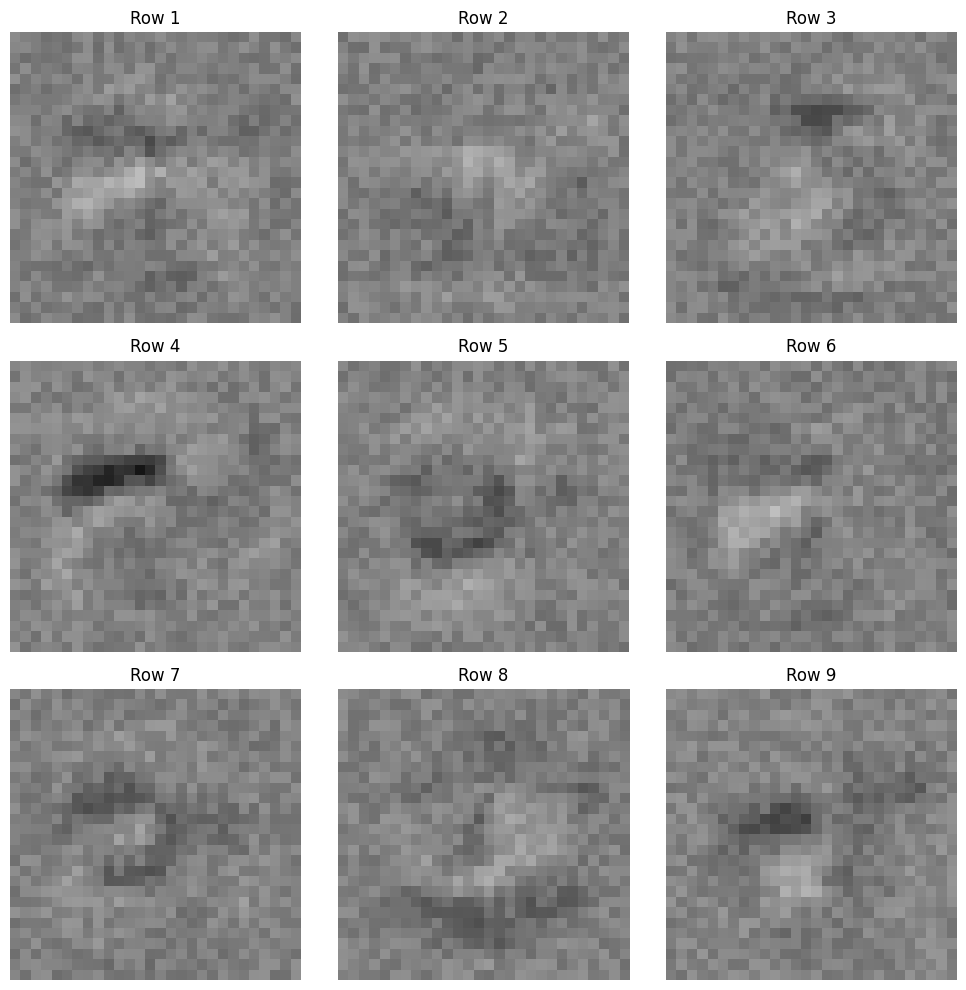

In [16]:
import matplotlib.pyplot as plt

weight_matrix = model.net[1].weight.detach().cpu()
weight_images = weight_matrix.view(256, 28, 28).numpy()

vmax = abs(weight_images).max()

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(weight_images[i], cmap='gray', vmin=-vmax, vmax=vmax)
    plt.title(f"Row {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()